Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset
(https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains information about various
houses in Boston through different parameters. There are 506 samples and 14 feature variables in this dataset.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load dataset
housing_data = fetch_california_housing()

housing_df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

In [3]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
print("Shape and Size: ", housing_df.shape, housing_df.size)
housing_df['PRICE'] = housing_data.target

Shape and Size:  (20640, 8) 165120


In [5]:
# Basic Info
print("Shape:", housing_df.shape)
print("\nColumns:\n", housing_df.columns)

Shape: (20640, 9)

Columns:
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'PRICE'],
      dtype='object')


In [6]:
print("\nSummary:\n")
housing_df.describe()


Summary:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Introduce missing values
housing_df.loc[housing_df.sample(frac=0.05).index, 'MedInc'] = np.nan
# Check missing values
print("\nMissing Values:\n", housing_df.isnull().sum())


Missing Values:
 MedInc        1032
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
PRICE            0
dtype: int64


In [8]:
# Handling missing values (mean imputation)
housing_df.fillna(housing_df.mean(), inplace=True)
# Check missing values
print("\nMissing Values:\n", housing_df.isnull().sum())


Missing Values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


In [9]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.325200,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.301400,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,3.871207,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: >

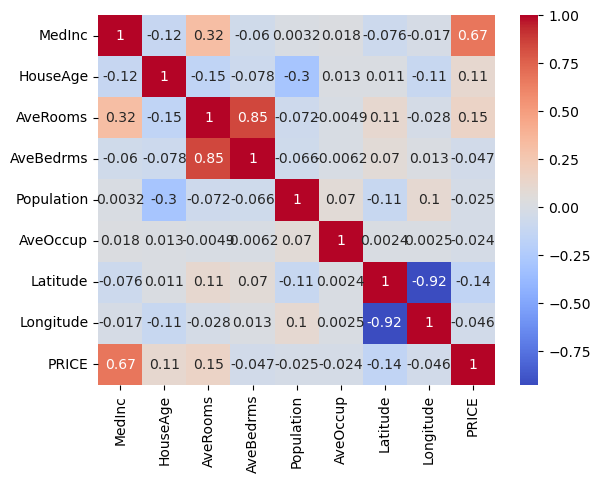

In [10]:
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm')

Number of outliers in PRICE: 1071
Outliers in PRICE:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
89   1.2434      52.0  2.929412   0.917647       396.0  4.658824     37.80   
140  6.3624      30.0  5.615385   0.730769       126.0  2.423077     37.81   
459  1.1696      52.0  2.436000   0.944000      1349.0  5.396000     37.87   
489  3.0417      48.0  4.690632   1.126362      1656.0  3.607843     37.86   
493  7.8521      52.0  7.794393   1.051402       517.0  2.415888     37.86   

     Longitude    PRICE  
89     -122.27  5.00001  
140    -122.18  4.83300  
459    -122.25  5.00001  
489    -122.25  4.89600  
493    -122.24  5.00001  
Lower bound: -0.9808749999999995, Upper bound: 4.824124999999999


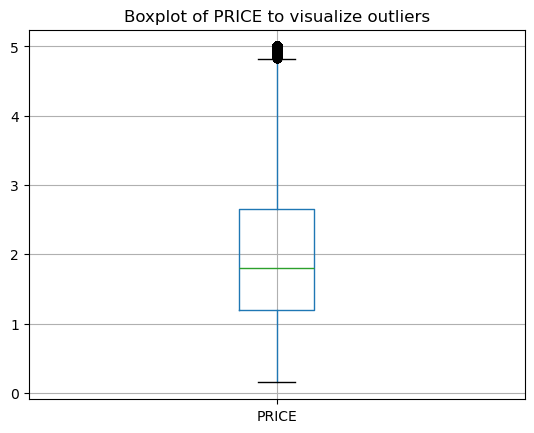

Original dataset shape: (20640, 9)
Cleaned dataset shape: (19569, 9)
Removed 1071 outliers


In [11]:
# Outlier Detection and Removal using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers in the PRICE column
outliers_price, lower_bound, upper_bound = detect_outliers_iqr(housing_df, 'PRICE')
print("Number of outliers in PRICE:", len(outliers_price))
print("Outliers in PRICE:")
print(outliers_price.head())  # Show first few outliers
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Visualize outliers using boxplot
housing_df.boxplot(column='PRICE')
plt.title('Boxplot of PRICE to visualize outliers')
plt.show()

# Remove outliers
housing_df_clean = housing_df[(housing_df['PRICE'] >= lower_bound) & (housing_df['PRICE'] <= upper_bound)]
print("Original dataset shape:", housing_df.shape)
print("Cleaned dataset shape:", housing_df_clean.shape)
print("Removed", len(housing_df) - len(housing_df_clean), "outliers")

# Update variables for cleaned data
X_clean = housing_df_clean.drop("PRICE", axis=1)
y_clean = housing_df_clean["PRICE"]


In [12]:
# Feature & Target split
X = housing_df.drop("PRICE", axis=1)
y = housing_df["PRICE"]

In [13]:
#Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [14]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
# Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Predictions
y_pred = model.predict(X_test_scaled)

In [17]:
# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("Model Performance")
print("==============================")
print("RMSE:", rmse)
print("R2 Score:", round(r2, 2))


Model Performance
RMSE: 0.7565788222433618
R2 Score: 0.58


In [18]:
# Cleaned dataset model training + evaluation
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=10
)

scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

model_clean = LinearRegression()
model_clean.fit(X_train_clean_scaled, y_train_clean)

y_pred_clean = model_clean.predict(X_test_clean_scaled)

rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
r2_clean = r2_score(y_test_clean, y_pred_clean)

print("\n==============================")
print("Model Performance on Cleaned Data")
print("==============================")
print("RMSE:", rmse_clean)
print("R2 Score:", round(r2_clean, 2))

print("\n==============================")
print("Comparison")
print("==============================")
print("Original RMSE:", rmse, "Cleaned RMSE:", rmse_clean)
print("Original R2:", round(r2, 2), "Cleaned R2:", round(r2_clean, 2))


Model Performance on Cleaned Data
RMSE: 0.6353594277585274
R2 Score: 0.55

Comparison
Original RMSE: 0.7565788222433618 Cleaned RMSE: 0.6353594277585274
Original R2: 0.58 Cleaned R2: 0.55


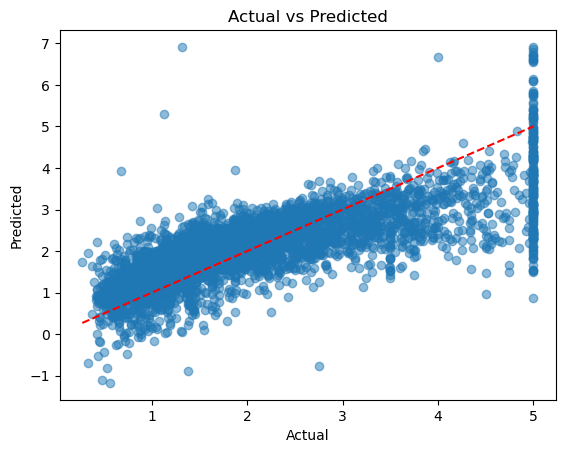

In [19]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()

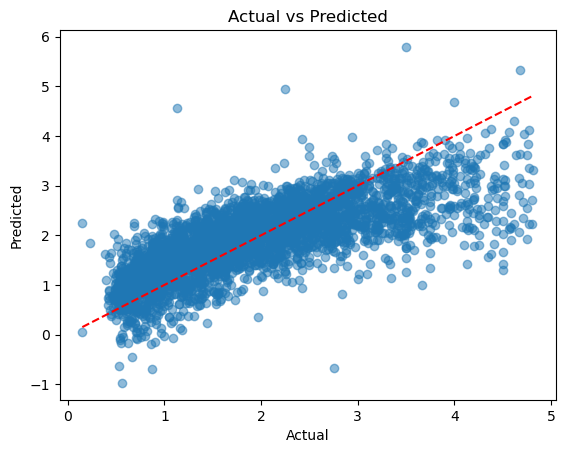

In [20]:
plt.scatter(y_test_clean, y_pred_clean, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([min(y_test_clean), max(y_test_clean)], [min(y_test_clean), max(y_test_clean)], 'r--')
plt.show()